# Tutorial de **Pandas** en Español — Cuaderno Didáctico Mejorado
_Generado: 2025-11-02 05:17_

> Este cuaderno combina teoría breve y ejemplos ejecutables paso a paso para que practiques Pandas en JupyterLab. Incluye lectura/escritura de datos, selección/filtrado, limpieza, agrupamientos, combinaciones y **gráficas** básicas.


## Objetivos de aprendizaje
- Comprender qué es **pandas** y cómo se integra con Python y NumPy.
- Crear, leer y explorar **Series** y **DataFrame**.
- Realizar **selección**, **filtrado** y **transformaciones** comunes.
- Aplicar **agrupamientos** y **agregaciones** para análisis descriptivo.
- Combinar tablas con **merge**, **concat** y **join**.
- **Limpiar datos**: nulos, duplicados y tipos.
- Exportar resultados a **CSV/Excel**.
- Generar **gráficas** básicas (histograma y barras) con `pandas.plot()` y **matplotlib**.


## Requisitos e instalación
Asegúrate de tener `pandas` instalado. En una terminal o celda de Jupyter, puedes ejecutar:

```bash
pip install pandas numpy matplotlib openpyxl
```

> `openpyxl` permite leer/escribir archivos Excel (`.xlsx`).



In [1]:
# Importaciones base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.__version__, np.__version__


('2.3.3', '2.3.4')

## 1. Introducción rápida a objetos de pandas
Los dos objetos principales son:

- **Series**: arreglo unidimensional etiquetado.
- **DataFrame**: tabla bidimensional con filas y columnas etiquetadas.


In [2]:
# Crear una Series y un DataFrame simples
s = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
df = pd.DataFrame({
    'producto': ['A', 'B', 'C', 'D'],
    'precio': [1000, 1500, 700, 1200],
    'stock': [10, 5, 20, 7]
})

display(s)
df


a    10
b    20
c    30
dtype: int64

,producto,precio,stock
0,A,1000,10
1,B,1500,5
2,C,700,20
3,D,1200,7


## 2. Creación y lectura de datos
Puedes crear datos manualmente o leerlos desde archivos CSV/Excel/JSON.

A continuación, generamos un **dataset de ejemplo** y lo guardamos en CSV para usarlo en el resto del cuaderno.


In [3]:
# Generar un dataset de ventas ficticio y guardarlo a disco (CSV)
rng = np.random.default_rng(42)
n = 100

df_ventas = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=n, freq='D'),
    'region': rng.choice(['Norte', 'Sur', 'Este', 'Oeste'], size=n),
    'vendedor': rng.choice(['Ana', 'Luis', 'Sofía', 'Carlos'], size=n),
    'producto': rng.choice(['A', 'B', 'C'], size=n),
    'cantidad': rng.integers(1, 10, size=n),
    'precio_unitario': rng.integers(10, 50, size=n).astype(float)
})
df_ventas['ingreso'] = df_ventas['cantidad'] * df_ventas['precio_unitario']

csv_path = 'datos_ventas.csv'
df_ventas.to_csv(csv_path, index=False)
csv_path, df_ventas.head()


('datos_ventas.csv',
        fecha region vendedor producto  cantidad  precio_unitario  ingreso
 0 2024-01-01  Norte   Carlos        B         4             49.0    196.0
 1 2024-01-02  Oeste      Ana        C         8             41.0    328.0
 2 2024-01-03   Este   Carlos        B         1             22.0     22.0
 3 2024-01-04    Sur      Ana        C         9             48.0    432.0
 4 2024-01-05    Sur   Carlos        B         5             29.0    145.0)

In [4]:
# Leer el CSV recién generado
df = pd.read_csv('datos_ventas.csv', parse_dates=['fecha'])
df.head()


,fecha,region,vendedor,producto,cantidad,precio_unitario,ingreso
0,2024-01-01,Norte,Carlos,B,4,49.0,196.0
1,2024-01-02,Oeste,Ana,C,8,41.0,328.0
2,2024-01-03,Este,Carlos,B,1,22.0,22.0
3,2024-01-04,Sur,Ana,C,9,48.0,432.0
4,2024-01-05,Sur,Carlos,B,5,29.0,145.0


## 3. Inspección y exploración de datos
Funciones clave:
- `head()`, `tail()` para vistas rápidas
- `info()` para estructura (tipos y nulos)
- `describe()` para estadísticas descriptivas


In [5]:
df.head(3), df.tail(3)

(       fecha region vendedor producto  cantidad  precio_unitario  ingreso
 0 2024-01-01  Norte   Carlos        B         4             49.0    196.0
 1 2024-01-02  Oeste      Ana        C         8             41.0    328.0
 2 2024-01-03   Este   Carlos        B         1             22.0     22.0,
         fecha region vendedor producto  cantidad  precio_unitario  ingreso
 97 2024-04-07   Este      Ana        B         2             24.0     48.0
 98 2024-04-08   Este     Luis        A         3             47.0    141.0
 99 2024-04-09  Norte   Carlos        A         3             27.0     81.0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            100 non-null    datetime64[ns]
 1   region           100 non-null    object        
 2   vendedor         100 non-null    object        
 3   producto         100 non-null    object        
 4   cantidad         100 non-null    int64         
 5   precio_unitario  100 non-null    float64       
 6   ingreso          100 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 5.6+ KB


In [7]:
df.describe()

,fecha,cantidad,precio_unitario,ingreso
count,100,100.000000,100.000000,100.000000
mean,2024-02-19 12:00:00,4.880000,29.860000,148.340000
min,2024-01-01 00:00:00,1.000000,10.000000,10.000000
25%,2024-01-25 18:00:00,3.000000,19.750000,57.750000
50%,2024-02-19 12:00:00,4.500000,30.000000,130.500000
75%,2024-03-15 06:00:00,7.000000,40.250000,227.250000
max,2024-04-09 00:00:00,9.000000,49.000000,432.000000
std,NaN,2.771719,12.066332,106.661574


## 4. Selección y filtrado
- Selección por **etiqueta**: `loc`
- Selección por **posición**: `iloc`
- **Filtrado** condicional por columnas


In [8]:
# Selección por columnas
df[['fecha', 'region', 'ingreso']].head()


,fecha,region,ingreso
0,2024-01-01,Norte,196.0
1,2024-01-02,Oeste,328.0
2,2024-01-03,Este,22.0
3,2024-01-04,Sur,432.0
4,2024-01-05,Sur,145.0


In [9]:
# Filtrado: ventas de la región 'Norte' con ingreso > 200
filtro = (df['region'] == 'Norte') & (df['ingreso'] > 200)
df.loc[filtro, ['fecha', 'region', 'ingreso']].head()


,fecha,region,ingreso
22,2024-01-23,Norte,240.0
40,2024-02-10,Norte,288.0
44,2024-02-14,Norte,270.0
55,2024-02-25,Norte,288.0
57,2024-02-27,Norte,315.0


## 5. Operaciones con columnas y filas
- Crear/eliminar/renombrar columnas
- Transformar valores con `apply`/`map`


In [10]:
# Crear una nueva columna categorizando el ingreso
def rango_ingreso(x):
    if x < 150:
        return 'bajo'
    elif x < 300:
        return 'medio'
    else:
        return 'alto'

df['rango_ingreso'] = df['ingreso'].apply(rango_ingreso)
df[['ingreso', 'rango_ingreso']].head()


,ingreso,rango_ingreso
0,196.0,medio
1,328.0,alto
2,22.0,bajo
3,432.0,alto
4,145.0,bajo


In [11]:
# Renombrar columnas
df_renombrado = df.rename(columns={'precio_unitario': 'precio'})
df_renombrado.head(2)


,fecha,region,vendedor,producto,cantidad,precio,ingreso,rango_ingreso
0,2024-01-01,Norte,Carlos,B,4,49.0,196.0,medio
1,2024-01-02,Oeste,Ana,C,8,41.0,328.0,alto


## 6. Agrupamiento y estadísticas
Usa `groupby` para calcular agregados por grupo (suma, media, conteos, etc.).


In [21]:
# Ingreso total por región
ingreso_por_region = df.groupby('region', as_index=False)['ingreso'].sum().sort_values('ingreso', ascending=False)
ingreso_por_region


,region,ingreso
2,Oeste,4743.0
3,Sur,4635.0
1,Norte,3119.0
0,Este,2337.0


In [22]:
# Agregados múltiples por producto
agg_producto = df.groupby('producto').agg(
    cantidad_total=('cantidad', 'sum'),
    ingreso_promedio=('ingreso', 'mean'),
    transacciones=('producto', 'count')
).reset_index()
agg_producto


,producto,cantidad_total,ingreso_promedio,transacciones
0,A,153,138.285714,35
1,B,186,159.729730,37
2,C,149,145.857143,28


## 7. Unión y combinación de DataFrames
- `pd.concat` apila datos (vertical/horizontal) cuando las columnas/índices lo permiten.
- `pd.merge` combina por **claves** comunes (estilo SQL).
- `df.join` une por índices.


In [14]:
# Ejemplo sencillo de merge: tabla de comisiones por vendedor
comisiones = pd.DataFrame({
    'vendedor': ['Ana', 'Luis', 'Sofía', 'Carlos'],
    'comision_pct': [0.05, 0.06, 0.055, 0.05]
})

df_merge = pd.merge(df, comisiones, on='vendedor', how='left')
df_merge[['vendedor', 'ingreso', 'comision_pct']].head()


,vendedor,ingreso,comision_pct
0,Carlos,196.0,0.05
1,Ana,328.0,0.05
2,Carlos,22.0,0.05
3,Ana,432.0,0.05
4,Carlos,145.0,0.05


In [23]:
# Calcular comisión monetaria
df_merge['comision_valor'] = df_merge['ingreso'] * df_merge['comision_pct']
df_merge[['vendedor', 'ingreso', 'comision_valor']].head()


,vendedor,ingreso,comision_valor
0,Carlos,196.0,9.80
1,Ana,328.0,16.40
2,Carlos,22.0,1.10
3,Ana,432.0,21.60
4,Carlos,145.0,7.25


## 8. Limpieza de datos
- Detección de nulos con `isna()` / `isnull()`
- Relleno de nulos con `fillna()`
- Eliminación de duplicados con `drop_duplicates()`


In [16]:
# Introducir nulos deliberadamente para el ejemplo
df_dirty = df.copy()
df_dirty.loc[df_dirty.sample(frac=0.05, random_state=1).index, 'cantidad'] = np.nan

df_dirty['cantidad'].isna().sum(), df_dirty.head(3)


(np.int64(5),
        fecha region vendedor producto  cantidad  precio_unitario  ingreso  \
 0 2024-01-01  Norte   Carlos        B       4.0             49.0    196.0   
 1 2024-01-02  Oeste      Ana        C       8.0             41.0    328.0   
 2 2024-01-03   Este   Carlos        B       1.0             22.0     22.0   
 
   rango_ingreso  
 0         medio  
 1          alto  
 2          bajo  )

In [17]:
# Rellenar nulos con la mediana (ejemplo)
mediana = df_dirty['cantidad'].median()
df_dirty['cantidad'] = df_dirty['cantidad'].fillna(mediana)
df_dirty['cantidad'].isna().sum()


np.int64(0)

In [18]:
# Eliminar filas duplicadas (si las hubiera)
antes = len(df_dirty)
df_dirty = df_dirty.drop_duplicates()
despues = len(df_dirty)
antes, despues


(100, 100)

## 9. Exportar datos
Guardar resultados a disco para compartir o persistir.


In [19]:
# Exportar agregados a CSV y Excel
out_csv = 'ingreso_por_region.csv'
out_xlsx = 'ingreso_por_region.xlsx'

ingreso_por_region.to_csv(out_csv, index=False)

with pd.ExcelWriter(out_xlsx) as writer:
    ingreso_por_region.to_excel(writer, index=False, sheet_name='ingreso_region')
    agg_producto.to_excel(writer, index=False, sheet_name='agg_producto')

out_csv, out_xlsx


ModuleNotFoundError: No module named 'openpyxl'

## 10. Visualización básica con `pandas.plot()` (matplotlib)
A continuación se muestran **dos ejemplos** de gráficas usando `pandas.plot()`.  
**Reglas que seguimos en este cuaderno:** usamos **matplotlib** (no seaborn), **una gráfica por figura** (sin subplots) y **sin especificar colores/estilos** manualmente.


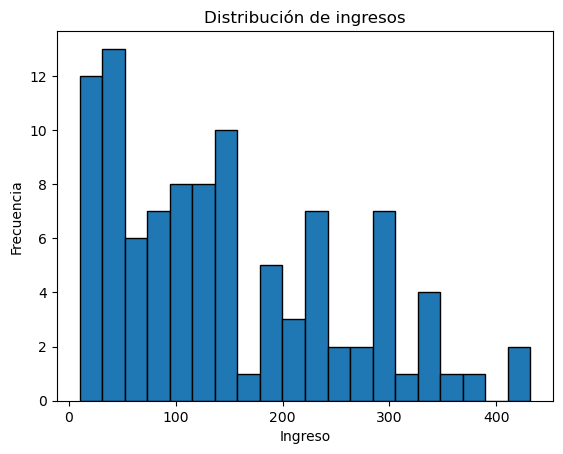

In [ ]:
# Histograma: distribución de ingresos
plt.figure()
df['ingreso'].plot(kind='hist', bins=20, edgecolor='black')
plt.title('Distribución de ingresos')
plt.xlabel('Ingreso')
plt.ylabel('Frecuencia')
plt.show()


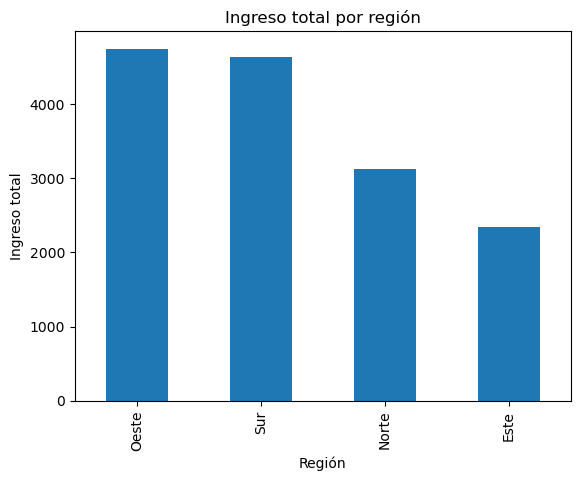

In [ ]:
# Barras: ingreso total por región
ingreso_por_region_plot = df.groupby('region', as_index=False)['ingreso'].sum().sort_values('ingreso', ascending=False)

plt.figure()
ingreso_por_region_plot.set_index('region')['ingreso'].plot(kind='bar')
plt.title('Ingreso total por región')
plt.xlabel('Región')
plt.ylabel('Ingreso total')
plt.show()


## 11. Conclusión y siguientes pasos
- Practicaste creación/lectura, exploración, selección/filtrado, limpieza, agrupaciones, combinaciones y gráficos.
- Siguientes pasos recomendados:
  - Profundizar en **índices** y **multi-índices** (`MultiIndex`).
  - Aprender **ventanas móviles** (`rolling`) y **resampleo** para series temporales.
  - Investigar rendimiento con **categorical dtypes** y operaciones vectorizadas.

**¡Sigue experimentando!** Modifica el dataset, añade columnas y crea nuevas visualizaciones.
